# Survival Analysis of IFN-γ and MYC Signatures in Diffuse Large B-Cell Lymphoma

This notebook evaluates the prognostic significance of key genes and pathway signatures identified in previous analyses of the GSE10846 DLBCL cohort.

Using Kaplan–Meier survival analysis and Cox proportional hazards modeling, we investigate whether dysregulated biological programs are associated with overall survival in R-CHOP-treated patients.

Objectives:

1. Assess the survival impact of leading-edge IFN-γ response genes.
2. Evaluate pathway-level prognostic signatures.
3. Determine whether IFN-γ and MYC pathway activity provide prognostic information beyond molecular subtype.
4. Develop an exploratory multivariate survival model.

## Background

Diffuse Large B-Cell Lymphoma (DLBCL) exhibits marked clinical heterogeneity. Patients with similar histological diagnoses can experience substantially different treatment outcomes.

Previous analyses in this project identified two major biological programs associated with the ABC subtype:

1. Interferon-gamma (IFN-γ) signaling
2. MYC target activation

Because both pathways have been implicated in lymphoma progression and immune regulation, we next investigate whether their activity is associated with patient survival.

Survival analysis allows us to determine whether specific genes or pathway signatures are linked to favorable or unfavorable clinical outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

from lifelines import CoxPHFitter

from sklearn.preprocessing import StandardScaler

In [2]:
expr_df = pd.read_csv("../data/processed/GSE10846_expr_matrx.csv",  index_col=0 )
meta_df = pd.read_csv("../data/processed/GSE10846_metadata.csv",  index_col=0 )

## Gene-Level Survival Analysis

To investigate the prognostic relevance of the Interferon Gamma (IFN-γ) response signature, we first performed univariate Cox proportional hazards regression on genes identified from the pathway analysis.

For each gene:

* Expression level was treated as a continuous variable.
* Overall survival time was used as the clinical outcome.
* Hazard ratios (HRs) and corresponding p-values were estimated independently.

Genes showing significant associations with survival were subsequently evaluated using Kaplan–Meier survival analysis. Patients were stratified into high- and low-expression groups based on median gene expression, and survival differences were assessed using the log-rank test.

This two-step approach enables both quantitative estimation of risk (Cox regression) and intuitive visualization of survival differences (Kaplan–Meier curves).


In [3]:
def kmSurvivalAnalysis(target_gene):
    if target_gene not in expr_df.index:
        raise ValueError(f"Gene {target_gene} not found in the expression matrix.")
    
    survival_df = pd.DataFrame({
    "Expression": expr_df.loc[target_gene],
    "Years": meta_df["Followup_years"],
    "Event": meta_df["Event_Status"] 
    })

    median_expression = survival_df["Expression"].median()
    survival_df["Group"] = np.where(survival_df["Expression"] > median_expression, "High Expression", "Low Expression")

    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()
    
    high_group = survival_df[survival_df["Group"] == "High Expression"]
    low_group = survival_df[survival_df["Group"] == "Low Expression"]

    plt.figure(figsize=(9, 6))
    
    kmf_high.fit(high_group["Years"], event_observed=high_group["Event"], label=f"High {target_gene} (n={len(high_group)})")
    kmf_high.plot_survival_function(color="#e74c3c", linewidth=2.5)
    
    kmf_low.fit(low_group["Years"], event_observed=low_group["Event"], label=f"Low {target_gene} (n={len(low_group)})")
    kmf_low.plot_survival_function(color="#3498db", linewidth=2.5)
    
    results = logrank_test(
        high_group["Years"], low_group["Years"],
        event_observed_A=high_group["Event"], event_observed_B=low_group["Event"]
    )
    p_value = results.p_value
        
    plt.title(f"Kaplan-Meier Survival Analysis for {target_gene}\nin R-CHOP Treated DLBCL Patients", fontsize=13, weight='bold')
    plt.xlabel("Survival Time (Years)", fontsize=11)
    plt.ylabel("Overall Survival Probability", fontsize=11)
    plt.ylim(0, 1.05)
    
    plt.grid(color='gray', linestyle=':', alpha=0.5)
    
    plt.text(
        x=0.5, y=0.15,  
        s=f"Log-Rank p-value: {p_value:.4f}", 
        fontsize=12, weight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
    )
    
    plt.tight_layout()
    plt.savefig(f"../results/figures/survival_{target_gene}.png", dpi=300)
    plt.show()
    
    print(f"Survival analysis for {target_gene} completed. Log-rank test p-value: {p_value:.6f}")

    return None

In [4]:
def univariateCoxAnalysis(gene_set):
    results = []
    for gene in gene_set:
        
        if gene not in expr_df.index:
            continue

        unicox_data = pd.DataFrame({
            "Expression": expr_df.loc[gene],
            "Years": meta_df["Followup_years"],
            "Event": meta_df["Event_Status"]
        })
        
        cph = CoxPHFitter()
        
        cph.fit(
            unicox_data,
            duration_col="Years",
            event_col="Event"
        )
        
        results.append({
            "Gene": gene,
            "HR": cph.summary.loc["Expression", "exp(coef)"],
            "p_value": cph.summary.loc["Expression", "p"]
        })

    univariate_results = pd.DataFrame(results)
    univariate_results = univariate_results.sort_values("p_value")
    print(univariate_results)

    top_genes = (
        univariate_results
        .query("p_value < 0.05")
        ["Gene"]
        .tolist()
    )

    for gene in top_genes:
        kmSurvivalAnalysis(gene)

     Gene        HR   p_value
4     PNP  1.958961  0.000201
5   CASP7  2.286889  0.005210
1    BPGM  1.414573  0.048486
6   PDE4B  1.255891  0.139327
2  IL10RA  1.244110  0.232145
0    IRF4  1.143744  0.256991
8  CXCL10  1.047573  0.613455
3    PIM1  1.058818  0.698287
7   PTPN1  1.039443  0.827822


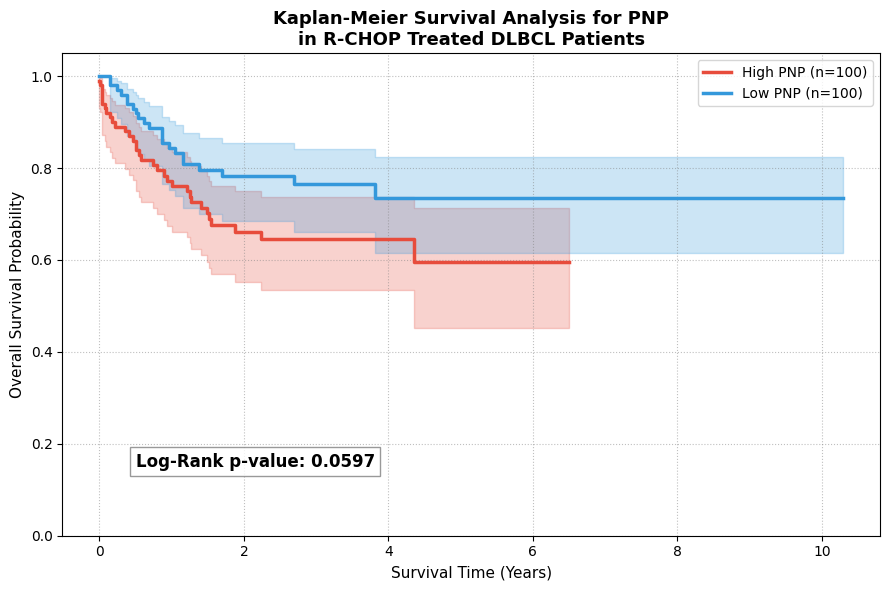

Survival analysis for PNP completed. Log-rank test p-value: 0.059685


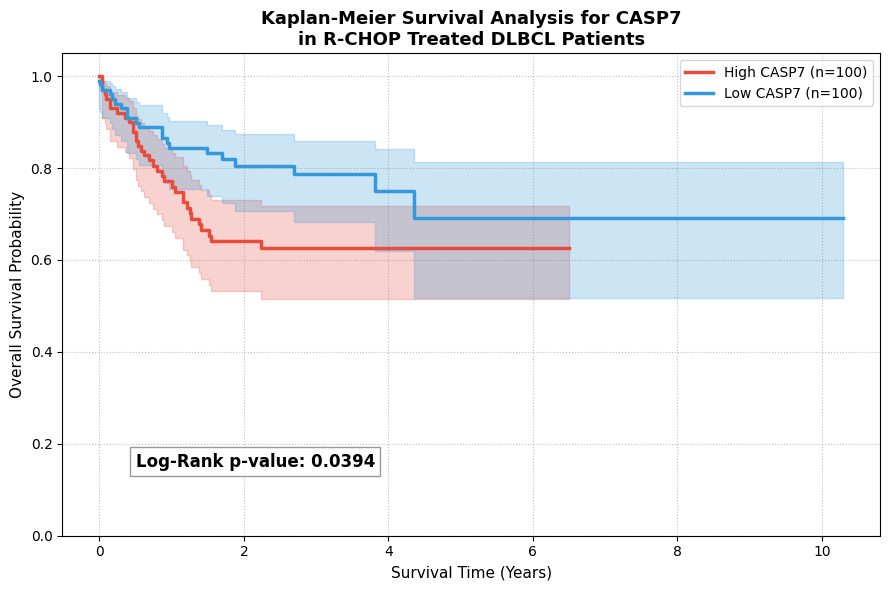

Survival analysis for CASP7 completed. Log-rank test p-value: 0.039356


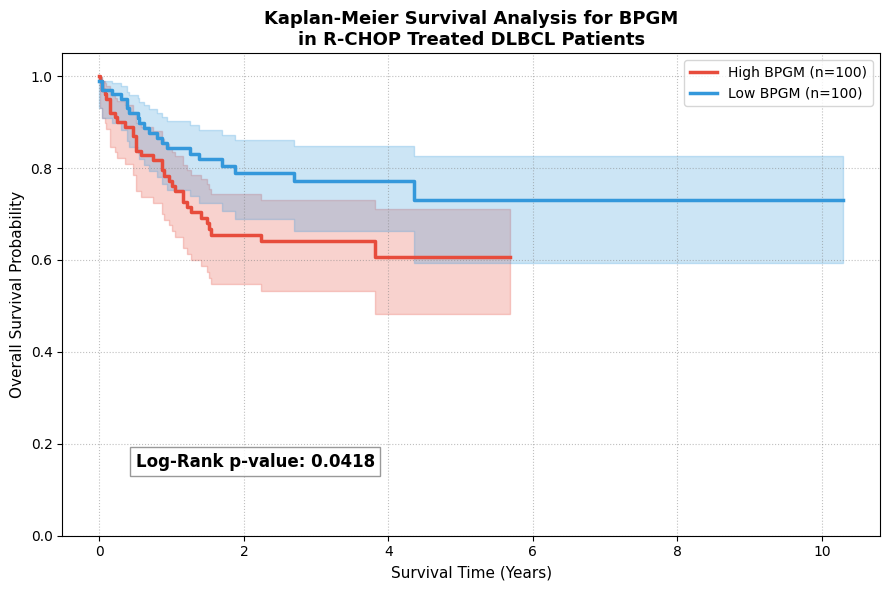

Survival analysis for BPGM completed. Log-rank test p-value: 0.041817


In [5]:
ifn_gamma_genes = ["IRF4", "BPGM", "IL10RA", "PIM1", "PNP", "CASP7", "PDE4B", "PTPN1", "CXCL10"]
univariateCoxAnalysis(ifn_gamma_genes)

## Results: Gene-Level Survival Associations

Univariate Cox regression identified several IFN-γ response genes associated with overall survival. Among the genes evaluated, PNP exhibited the strongest association with poor prognosis, followed by CASP7 and BPGM. 

Kaplan–Meier survival analysis further demonstrated that patients with high expression of these genes generally experienced poorer outcomes than those with low expression. The separation between survival curves was most pronounced for CASP7 and BPGM, both of which showed statistically significant differences in survival probability. PNP demonstrated a similar trend toward poorer survival in the high-expression group, although the log-rank test did not reach conventional statistical significance. PNP is a highly significant predictor of survival on a continuous scale ($p < 0.001$), even though artificial median splitting on the KM curve sits just on the cusp of significance ($p = 0.0597$)

Biologically, these findings suggest that activation of specific components of the IFN-γ response program may be associated with more aggressive disease behavior. PNP is involved in purine metabolism and immune-cell function, CASP7 plays a central role in apoptotic signaling, and BPGM contributes to cellular metabolic regulation. Elevated expression of these genes may therefore reflect broader inflammatory, metabolic, and stress-response programs associated with adverse clinical outcomes in DLBCL.


## Pathway-Level Survival Analysis

Individual genes can be noisy biomarkers due to biological variability.

To obtain a more robust estimate of pathway activity, expression values were standardized and averaged across multiple genes within each pathway.

Two pathway signatures were investigated:

- MYC Target Signature
- IFN-γ Response Signature

Patients were stratified into high-activity and low-activity groups based on median pathway scores.

In [6]:
def pathwaySurvival(pathway_name, pathway_genes):
    valid_genes = [g for g in pathway_genes if g in expr_df.index]
    
    pathway_expr = expr_df.loc[valid_genes]
    pathway_scaled = pathway_expr.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
    
    patient_pathway_scores = pathway_scaled.mean(axis=0)
    
    
    pathway_survival_df = pd.DataFrame({
        "Pathway_Score": patient_pathway_scores,
        "Years": meta_df["Followup_years"],
        "Event": meta_df["Event_Status"]
    })
    
    median_score = pathway_survival_df["Pathway_Score"].median()
    pathway_survival_df["Group"] = np.where(
        pathway_survival_df["Pathway_Score"] > median_score, 
        "High Pathway Activity", 
        "Low Pathway Activity"
    )
    
    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()
    
    high_group = pathway_survival_df[pathway_survival_df["Group"] == "High Pathway Activity"]
    low_group = pathway_survival_df[pathway_survival_df["Group"] == "Low Pathway Activity"]
    
    plt.figure(figsize=(9, 6))
    
    kmf_high.fit(high_group["Years"], event_observed=high_group["Event"], label=f"High {pathway_name} Activity (n={len(high_group)})")
    kmf_high.plot_survival_function(color="#d35400", linewidth=2.5) # Dark Orange
    
    kmf_low.fit(low_group["Years"], event_observed=low_group["Event"], label=f"Low {pathway_name} Activity (n={len(low_group)})")
    kmf_low.plot_survival_function(color="#2c3e50", linewidth=2.5)  # Midnight Blue
    
    pathway_results = logrank_test(
        high_group["Years"], low_group["Years"],
        event_observed_A=high_group["Event"], event_observed_B=low_group["Event"]
    )
    
    plt.title(f"Kaplan-Meier Survival Analysis: {pathway_name} Signature\n(R-CHOP Treated DLBCL Patients)", fontsize=13, weight='bold')
    plt.xlabel("Survival Time (Years)", fontsize=11)
    plt.ylabel("Overall Survival Probability", fontsize=11)
    plt.ylim(0, 1.05)
    plt.grid(color='gray', linestyle=':', alpha=0.5)
    
    plt.text(
        x=0.5, y=0.15, 
        s=f"Log-Rank p-value: {pathway_results.p_value:.4f}", 
        fontsize=12, weight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
    )
    
    plt.tight_layout()
    plt.savefig(f"../results/figures/survival_{pathway_name}.png", dpi=300)
    plt.show()
    
    print(f"Pathway survival analysis complete. P-value: {pathway_results.p_value:.6f}")

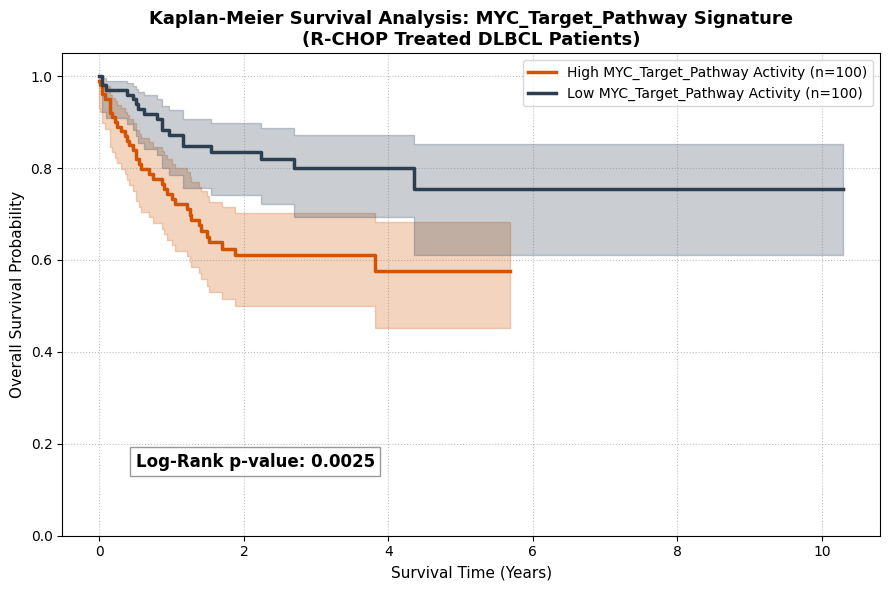

Pathway survival analysis complete. P-value: 0.002473


In [7]:
myc_pathway_genes = ["ABCE1", "ETF1", "CANX", "APEX1", "NPM1", "RRP9", "GLO1", "SRM", "SNRPD"]
pathwaySurvival("MYC_Target_Pathway", myc_pathway_genes)

### MYC Target Pathway

MYC is a master transcription factor that regulates cellular growth, metabolism, and proliferation.

Patients with elevated MYC pathway activity showed significantly poorer survival outcomes compared with those exhibiting lower pathway activity.

This finding is consistent with the established role of MYC activation as a driver of aggressive lymphoma behavior.

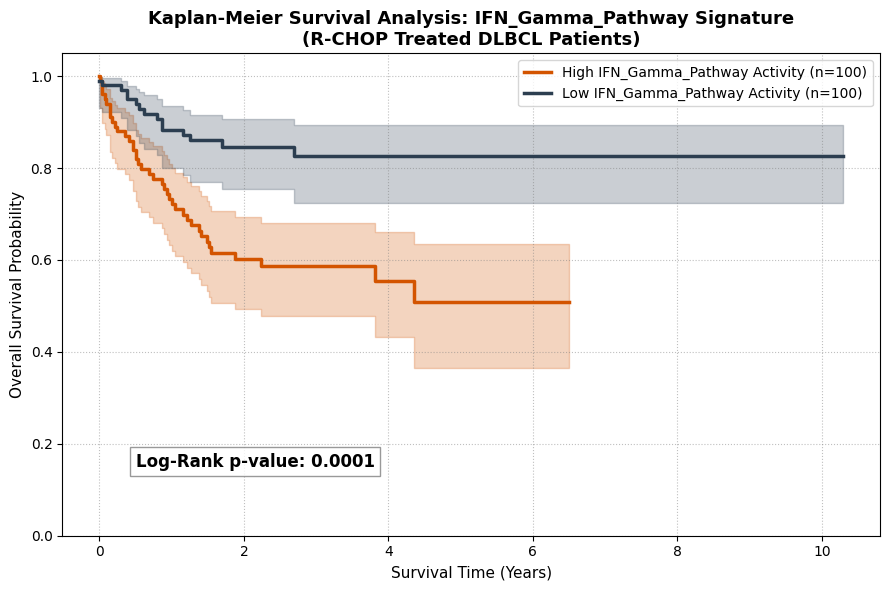

Pathway survival analysis complete. P-value: 0.000109


In [8]:
ifn_gamma_pathway_genes = ["IRF4", "BPGM", "IL10RA", "PIM1", "PNP", "CASP7", "PDE4B", "PTPN1", "CXCL10"]
pathwaySurvival("IFN_Gamma_Pathway",ifn_gamma_pathway_genes)

### IFN-γ Response Pathway

The IFN-γ response signature demonstrated a strong association with survival.

Patients with elevated IFN-γ pathway activity experienced substantially worse overall survival.

This suggests that chronic inflammatory signaling may contribute to disease progression and treatment resistance in DLBCL.

In [9]:
valid_ifn = [g for g in ifn_gamma_pathway_genes if g in expr_df.index]
valid_myc = [g for g in myc_pathway_genes if g in expr_df.index]

ifn_scores = expr_df.loc[valid_ifn].apply(lambda x: (x - x.mean()) / x.std(), axis=1).mean(axis=0)
myc_scores = expr_df.loc[valid_myc].apply(lambda x: (x - x.mean()) / x.std(), axis=1).mean(axis=0)

strat_df = pd.DataFrame({
    "IFN_Score": ifn_scores,
    "MYC_Score": myc_scores,
    "Subtype": meta_df["Subtype"],
    "Years": meta_df["Followup_years"],
    "Event": meta_df["Event_Status"]
})

## Subtype-Specific Survival Analysis

Because ABC and GCB DLBCL represent biologically distinct diseases, pathway activity may have different prognostic implications within each subtype.

To investigate this possibility, IFN-γ pathway activity was evaluated separately in ABC and GCB patients.

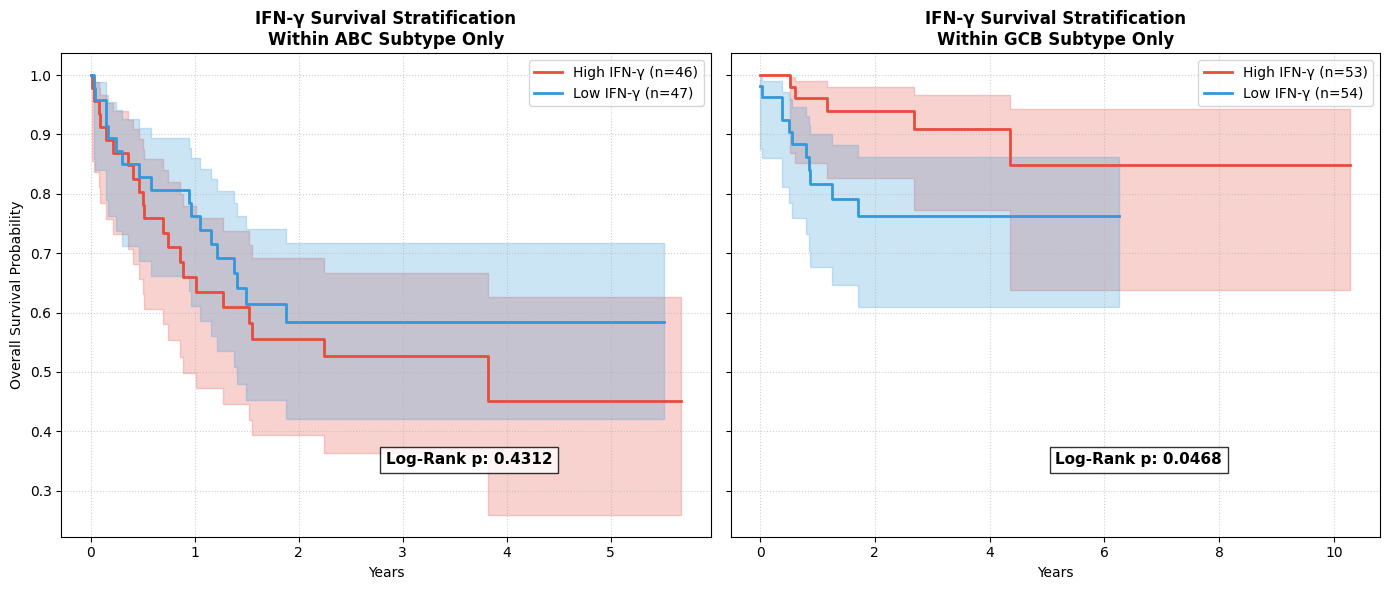

In [10]:
subtypes = ["ABC", "GCB"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, sub in enumerate(subtypes):
    sub_df = strat_df[strat_df["Subtype"] == sub].copy()
    
   
    med_ifn = sub_df["IFN_Score"].median()
    sub_df["IFN_Group"] = np.where(sub_df["IFN_Score"] > med_ifn, "High IFN-γ", "Low IFN-γ")
    
    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()
    
    high = sub_df[sub_df["IFN_Group"] == "High IFN-γ"]
    low = sub_df[sub_df["IFN_Group"] == "Low IFN-γ"]
    
    
    kmf_high.fit(high["Years"], event_observed=high["Event"], label=f"High IFN-γ (n={len(high)})")
    kmf_high.plot_survival_function(ax=axes[i], color="#e74c3c", linewidth=2)
    
    kmf_low.fit(low["Years"], event_observed=low["Event"], label=f"Low IFN-γ (n={len(low)})")
    kmf_low.plot_survival_function(ax=axes[i], color="#3498db", linewidth=2)
    
   
    lr_res = logrank_test(high["Years"], low["Years"], event_observed_A=high["Event"], event_observed_B=low["Event"])
    
    axes[i].set_title(f"IFN-γ Survival Stratification\nWithin {sub} Subtype Only", fontsize=12, weight='bold')
    axes[i].set_xlabel("Years")
    axes[i].grid(linestyle=':', alpha=0.6)
    axes[i].text(0.5, 0.15, f"Log-Rank p: {lr_res.p_value:.4f}", transform=axes[i].transAxes, 
                 fontsize=11, weight='bold', bbox=dict(facecolor='white', alpha=0.8))

axes[0].set_ylabel("Overall Survival Probability")
plt.tight_layout()
plt.savefig(f"../results/figures/stratified_survival_ifn_gamma.png", dpi=300)
plt.show()

## Results: Subtype-Specific Effects

Interestingly, the prognostic value of the IFN-γ signature differed between molecular subtypes.

Findings:

- No significant association was observed within the ABC subtype.
- A significant survival difference was observed within the GCB subtype.

These results suggest that the biological consequences of IFN-γ signaling may depend on the broader molecular context of the tumor.

Therefore, IFN-γ activity appears to provide greater prognostic information in GCB DLBCL than in ABC DLBCL. Within the GCB subtype, high IFN-γ actually provides a survival benefit.

## Multivariate Cox Proportional Hazards Modeling

Univariate analyses evaluate each variable independently.

To determine whether IFN-γ and MYC pathway activity provide prognostic information beyond molecular subtype, a multivariate Cox proportional hazards model was constructed.

The model included:

- IFN-γ pathway score
- MYC pathway score
- DLBCL subtype (ABC vs GCB)

This approach allows estimation of the independent contribution of each factor while adjusting for the others.

=== MULTIVARIATE COX PH MODEL RESULTS ===
                    coef  exp(coef)  se(coef)         p
covariate                                              
IFN_Score      -0.325051   0.722490  0.246501  0.187283
MYC_Score       0.218597   1.244330  0.178123  0.219737
Is_ABC_Subtype  1.468285   4.341784  0.536774  0.006231


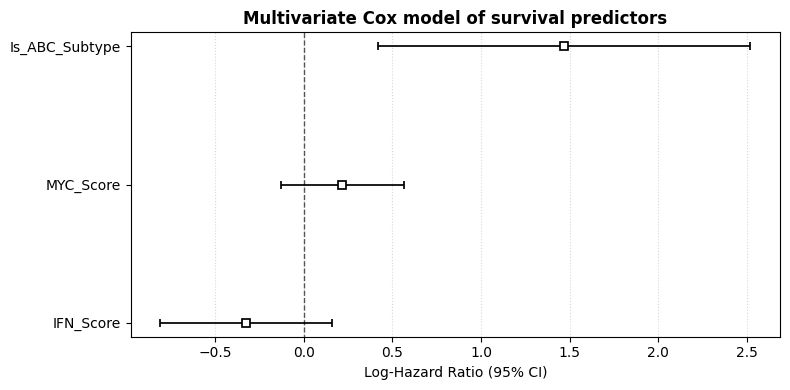

In [11]:
# 1. Prepare data for Cox model
cox_multivariate_data = strat_df[["IFN_Score", "MYC_Score", "Years", "Event"]].copy()

cox_multivariate_data[["IFN_Score", "MYC_Score"]] = StandardScaler().fit_transform(
    cox_multivariate_data[["IFN_Score", "MYC_Score"]]
)

# Convert categorical Subtype into a binary variable (GCB = 0, ABC = 1)
cox_multivariate_data["Is_ABC_Subtype"] = strat_df["Subtype"].map({"GCB": 0, "ABC": 1})

# 2. Initialize and fit the model
cph_multi = CoxPHFitter()
cph_multi.fit(
    df=cox_multivariate_data,
    duration_col="Years",
    event_col="Event"
)

# 3. Print the summary table (using raw DataFrame access to prevent styling crashes)
print("=== MULTIVARIATE COX PH MODEL RESULTS ===")
print(cph_multi.summary[["coef", "exp(coef)", "se(coef)", "p"]])

# 4. Plot the Forest Plot
plt.figure(figsize=(8, 4))
cph_multi.plot()
plt.title("Multivariate Cox model of survival predictors", fontsize=12, weight='bold')
plt.xlabel("Log-Hazard Ratio (95% CI)")
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f"../results/figures/multivariate_cox_model", dpi=300)
plt.show()

## Results: Multivariate Survival Model

After adjustment for subtype:

- IFN-γ pathway activity was no longer independently significant.
- MYC pathway activity was no longer independently significant.
- ABC subtype remained a significant predictor of poor survival.

The ABC subtype was associated with approximately 4.3-fold higher hazard compared with GCB tumors.

These findings suggest that molecular subtype captures much of the prognostic information represented by IFN-γ and MYC pathway activity.

In [12]:
cph_multi.concordance_index_

np.float64(0.680033120416371)


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.4360)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3980)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4453)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4964)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6889)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5980)'>]]

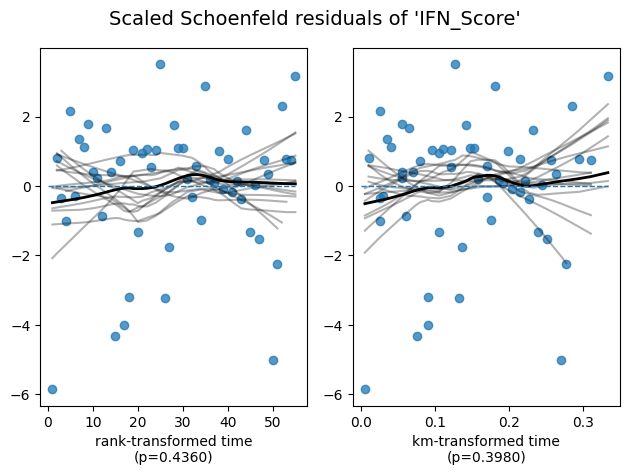

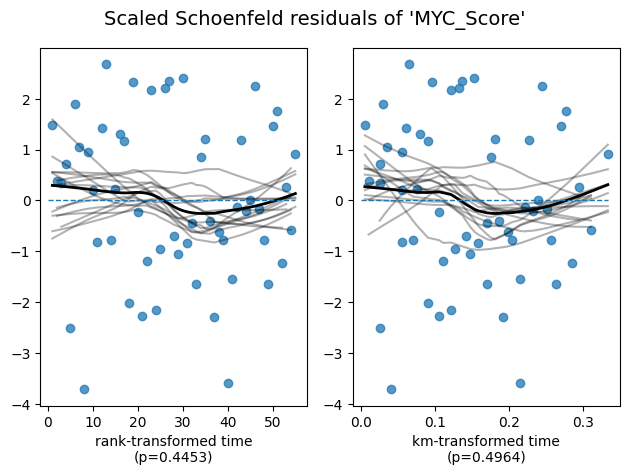

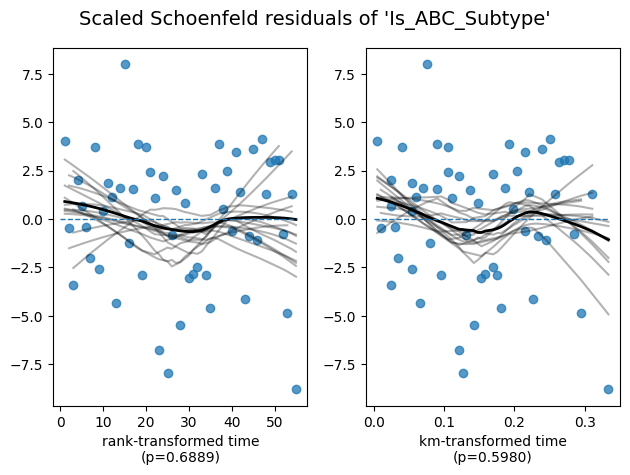

In [13]:
cph_multi.check_assumptions(cox_multivariate_data, show_plots=True)

## Model Diagnostics

The proportional hazards assumption was evaluated using Schoenfeld residuals.

No significant violations were detected, supporting the validity of the Cox proportional hazards model.

This indicates that the estimated hazard ratios remained reasonably stable throughout the follow-up period.

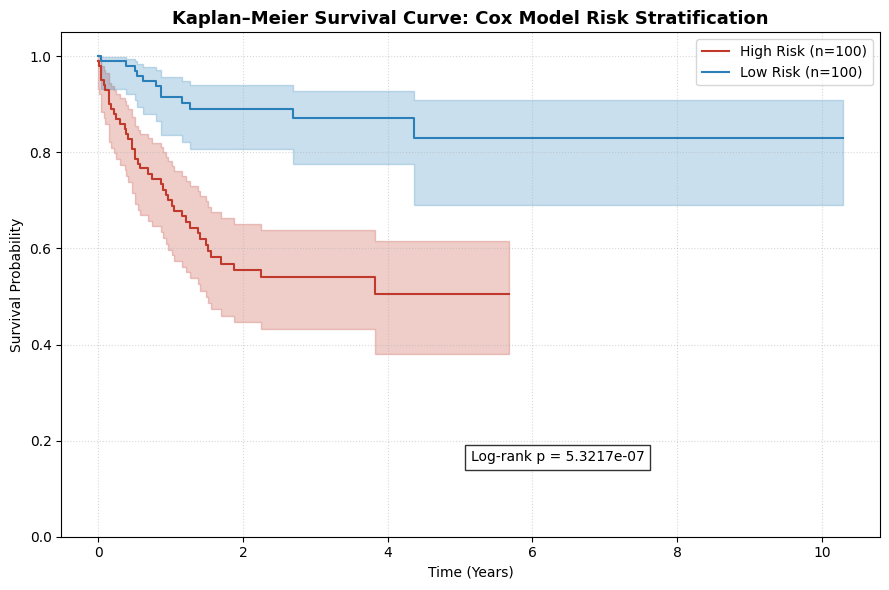

In [14]:
cox_multivariate_data["RiskScore"] = cph_multi.predict_partial_hazard(cox_multivariate_data)
median_risk = cox_multivariate_data["RiskScore"].median()

cox_multivariate_data["RiskGroup"] = np.where(
    cox_multivariate_data["RiskScore"] >= median_risk,
    "High Risk",
    "Low Risk"
)

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

high_group = cox_multivariate_data[cox_multivariate_data["RiskGroup"] == "High Risk"]
low_group = cox_multivariate_data[cox_multivariate_data["RiskGroup"] == "Low Risk"]

plt.figure(figsize=(9,6))

# Fit high risk
kmf_high.fit(
    durations=high_group["Years"],
    event_observed=high_group["Event"],
    label=f"High Risk (n={len(high_group)})"
)
kmf_high.plot_survival_function(ci_show=True, color="#c0392b")

# Fit low risk
kmf_low.fit(
    durations=low_group["Years"],
    event_observed=low_group["Event"],
    label=f"Low Risk (n={len(low_group)})"
)
kmf_low.plot_survival_function(ci_show=True, color="#2980b9")

# Log-rank test
results = logrank_test(
    high_group["Years"], low_group["Years"],
    event_observed_A=high_group["Event"],
    event_observed_B=low_group["Event"]
)

p_value = results.p_value

# Plot formatting
plt.title("Kaplan–Meier Survival Curve: Cox Model Risk Stratification", 
          fontsize=13, weight="bold")
plt.xlabel("Time (Years)")
plt.ylabel("Survival Probability")
plt.ylim(0, 1.05)

# p-value annotation
plt.text(
    0.5, 0.15,
    f"Log-rank p = {p_value:.4e}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(f"../results/figures/KM_cox_stratified.png", dpi=300)
plt.show()

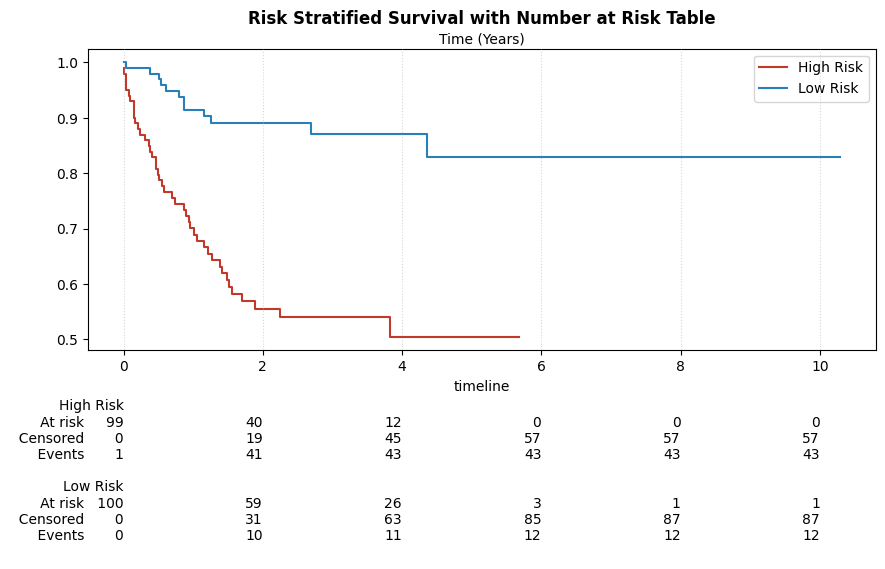

In [15]:
plt.figure(figsize=(9,6))

ax = plt.subplot(111)

kmf_high.fit(high_group["Years"], event_observed=high_group["Event"], label="High Risk")
kmf_low.fit(low_group["Years"], event_observed=low_group["Event"], label="Low Risk")

kmf_high.plot_survival_function(ax=ax, ci_show=False, color="#c0392b")
kmf_low.plot_survival_function(ax=ax, ci_show=False, color="#2980b9")

add_at_risk_counts(kmf_high, kmf_low, ax=ax)

plt.title("Risk Stratified Survival with Number at Risk Table", weight="bold")
plt.xlabel("Time (Years)")
plt.ylabel("Survival Probability")

plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(f"../results/figures/KM_table_risk_stratified.png", dpi=300)
plt.show()

## Risk Stratification

Risk scores were calculated using the fitted multivariate Cox model.

Patients were divided into:

- High-risk group
- Low-risk group

based on the median predicted risk score.

The resulting Kaplan–Meier curves demonstrated substantial separation between risk groups, indicating that the model successfully captured clinically relevant survival differences within the cohort.

Because the model was evaluated in the same dataset used for model training, these results should be interpreted as internal validation rather than evidence of external predictive performance.

# Conclusions

This survival analysis identified clinically relevant transcriptional programs associated with outcome in DLBCL.

Key findings:

- Several IFN-γ response genes were associated with poorer survival.
- Elevated MYC pathway activity predicted unfavorable outcomes.
- IFN-γ pathway activity demonstrated subtype-specific prognostic effects, particularly within GCB tumors.
- ABC subtype remained the strongest independent predictor of survival after multivariate adjustment.
- A multivariate Cox model achieved moderate prognostic performance (C-index = 0.68).

Overall, these results highlight the importance of inflammatory signaling and MYC-driven transcriptional programs in DLBCL biology and prognosis.